In [17]:
#Проектный анализ

In [1]:
import pandas as pd

In [15]:
##Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа

In [2]:
customers = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-anna-tsoj-syp9958/olist_customers_dataset.csv')

In [3]:
orders = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-anna-tsoj-syp9958/olist_orders_dataset.csv')

In [61]:
items = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-anna-tsoj-syp9958/olist_order_items_dataset.csv')

In [16]:
user_orders = pd.merge(customers, orders, on='customer_id', how='inner')

In [7]:
user_orders.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00


In [8]:
print(user_orders['order_purchase_timestamp'].dtypes)

object


In [9]:
user_orders['order_purchase_timestamp'] = pd.to_datetime(user_orders['order_purchase_timestamp'])

In [18]:
print(user_orders['order_status'].value_counts())

delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64


In [33]:
###Исследовать датасет и определить, какой вид заказа будет учитываться в retention

In [20]:
active_orders = user_orders[user_orders['order_status'].isin(['delivered', 'shipped', 'approved', 'processing'])]

In [23]:
active_orders = user_orders[user_orders['order_status'].isin(['delivered', 'shipped', 'approved', 'processing'])].copy()
active_orders['order_purchase_timestamp'] = pd.to_datetime(active_orders['order_purchase_timestamp'])
active_orders['order_month'] = active_orders['order_purchase_timestamp'].dt.to_period('M')

In [24]:
active_orders['cohort_month'] = active_orders.groupby('customer_unique_id')['order_month'].transform('min')

In [25]:
print(active_orders[['customer_unique_id', 'order_month', 'cohort_month']].head())

                 customer_unique_id order_month cohort_month
0  861eff4711a542e4b93843c6dd7febb0     2017-05      2017-05
1  290c77bc529b7ac935b93aa66c333dc3     2018-01      2018-01
2  060e732b5b29e8181a18229c7b0b2b5e     2018-05      2018-05
3  259dac757896d24d7702b9acbbff3f3c     2018-03      2018-03
4  345ecd01c38d18a9036ed96c73b8d066     2018-07      2018-07


In [26]:
active_orders['cohort_index'] = (active_orders['order_month'] - active_orders['cohort_month']).apply(lambda x: x.n)

In [27]:
print(active_orders[['customer_unique_id', 'order_month', 'cohort_month', 'cohort_index']].head())

                 customer_unique_id order_month cohort_month  cohort_index
0  861eff4711a542e4b93843c6dd7febb0     2017-05      2017-05             0
1  290c77bc529b7ac935b93aa66c333dc3     2018-01      2018-01             0
2  060e732b5b29e8181a18229c7b0b2b5e     2018-05      2018-05             0
3  259dac757896d24d7702b9acbbff3f3c     2018-03      2018-03             0
4  345ecd01c38d18a9036ed96c73b8d066     2018-07      2018-07             0


In [34]:
###Построить месячный retention

In [28]:
cohort_group = active_orders.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()

In [29]:
cohort_pivot = cohort_group.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id')

In [31]:
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

In [32]:
retention_matrix.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003676,NaN,NaN,0.003676,NaN,0.003676,NaN,0.003676,NaN,0.003676,NaN,0.003676,0.007353,0.007353
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.004054,0.002703,0.001351,0.004054,0.001351,0.004054,0.001351,0.001351,NaN,0.004054,0.001351,0.006757,0.004054,0.001351,0.001351,0.002703,0.004054,0.001351,NaN
2017-02,1.0,0.002382,0.002978,0.001191,0.004169,0.001191,0.002382,0.001787,0.001191,0.001787,0.001191,0.002978,0.001191,0.001787,0.001191,0.000596,0.000596,0.002382,NaN,NaN


In [37]:
###Проанализировать, чему равен медианный retention 1-го месяца

In [90]:
retention_rate = retention_matrix[1].median()
print(f"Медианный retention 1-го месяца: {median_ret_1:.4f} (или {median_ret_1 * 100:.2f}%)")

Медианный retention 1-го месяца: 0.0051 (или 0.51%)


In [39]:
###Найти когорту с самым высоким retention на 3-й месяц

In [40]:
best_cohort_3 = retention_matrix[3].idxmax()
best_value_3 = retention_matrix[3].max()

print(f"Когорта с самым высоким удержанием на 3-й месяц: {best_cohort_3} (значение: {best_value_3 * 100:.2f}%)")

Когорта с самым высоким удержанием на 3-й месяц: 2017-05 (значение: 0.40%)


In [41]:
###Проиллюстрировать результаты релевантной визуализацией

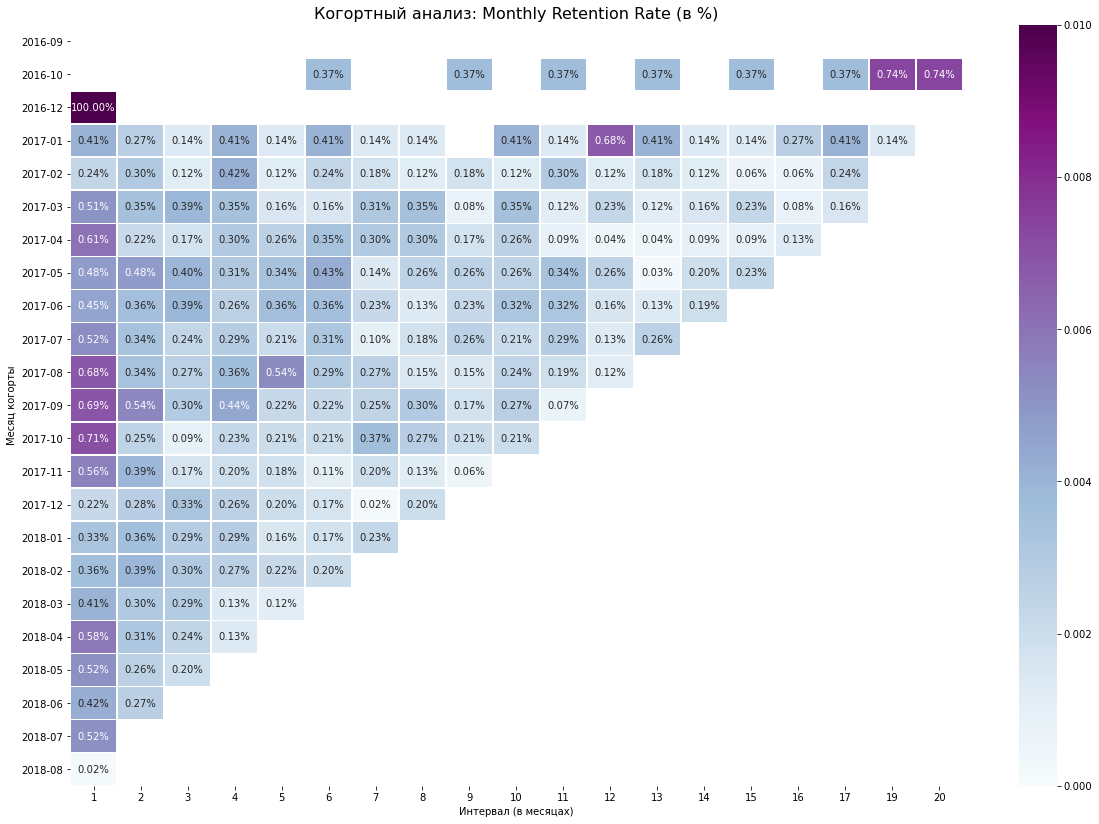

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = retention_matrix.drop(columns=[0])
plt.figure(figsize=(20, 14))
plt.title('Когортный анализ: Monthly Retention Rate (в %)', fontsize=16)

sns.heatmap(plot_data, 
            annot=True,             
            fmt='.2%',              
            cmap='BuPu',           
            vmin=0.0, 
            vmax=0.01,               
            linewidths=0.5)         

plt.ylabel('Месяц когорты')
plt.xlabel('Интервал (в месяцах)')
plt.show()

In [46]:
##Задача 2. Определить, существует ли product/market fit у маркетплейса.

In [54]:
###Выводы: PMF отсутствует. Удержание находится на критически низком уровне (меньше 1). Клиенты совершают разовую покупку и не возвращаются, а значит, продукт пока не удовлетворяет их долгосрочные потребности.Причины отсутствия PMF: Сложная или слишком долгая логистика (товары из Бразилии могут идти месяцами, что портит клиентский опыт).
###Специфика ассортимента (возможно, люди покупают какие-то уникальные или сувенирные товары, которые просто не нужны им регулярно).
###Проблемы с качеством товара или неоправданные ожидания при первой покупке.
###Рекомендации: Советую временно приостановить масштабирование и затраты на маркетинг. Вместо этого предлагаю сфокусироваться на исследовании текущих клиентов: провести проблемные интервью (CustDev), запустить опросы тех, кто совершил покупку, но не вернулся, и детально проанализировать логистическую цепочку.

In [56]:
###Визуализация выводов

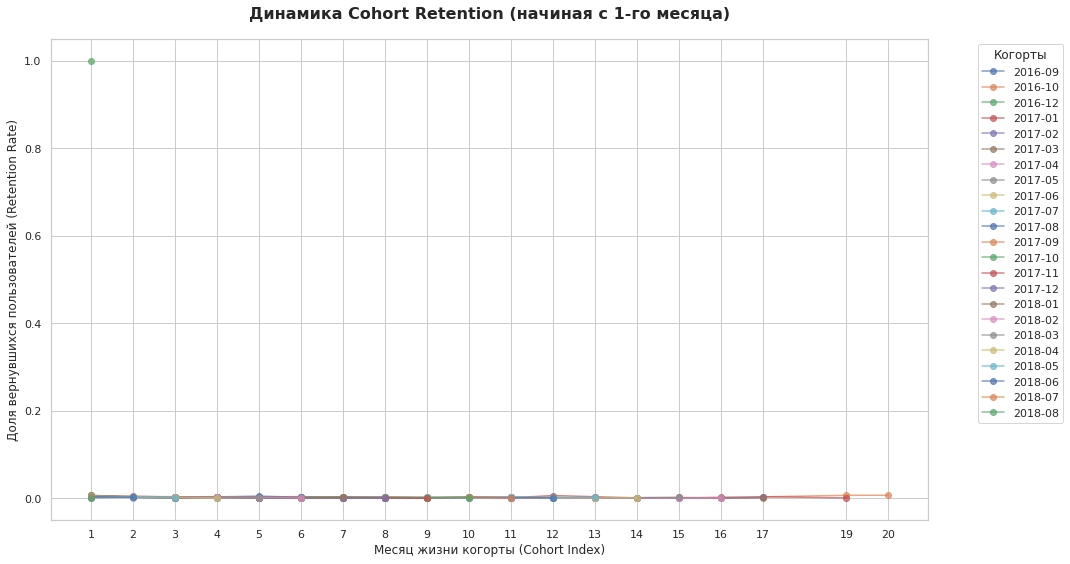

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plot_data = retention_matrix.drop(columns=[0])
plt.figure(figsize=(15, 8))
plt.plot(plot_data.T, marker='o', alpha=0.7)

plt.title('Динамика Cohort Retention (начиная с 1-го месяца)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Месяц жизни когорты (Cohort Index)', fontsize=12)
plt.ylabel('Доля вернувшихся пользователей (Retention Rate)', fontsize=12)

plt.xticks(plot_data.columns)
plt.legend(plot_data.index, title='Когорты', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [60]:
##Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

In [63]:
sales_data = active_orders.merge(items, on='order_id', how='inner')

In [65]:
sales_data['month'] = sales_data['order_purchase_timestamp'].dt.to_period('M')

In [68]:
gmv_monthly = sales_data.groupby('month')['price'].sum().reset_index()
gmv_monthly.columns = ['month', 'gmv']

In [70]:
mau_monthly = sales_data.groupby('month')['customer_unique_id'].nunique().reset_index()
mau_monthly.columns = ['month', 'mau']

In [74]:
user_orders_per_month = sales_data.groupby(['month', 'customer_unique_id'])['order_id'].nunique().reset_index()
user_orders_per_month['is_repeat'] = user_orders_per_month['order_id'] > 1

In [75]:
repeat_rate_monthly = user_orders_per_month.groupby('month').agg(
    total_users=('customer_unique_id', 'count'),
    repeat_users=('is_repeat', 'sum')
).reset_index()

In [76]:
repeat_rate_monthly['repeat_rate'] = repeat_rate_monthly['repeat_users'] / repeat_rate_monthly['total_users']

In [72]:
arppu_monthly = gmv_monthly.merge(mau_monthly, on='month')
arppu_monthly['arppu'] = arppu_monthly['gmv'] / arppu_monthly['mau']

In [79]:
###Первая метрика. Рост объема продаж: здесь идеально подойдет GMV (Gross Merchandise Value) — общая стоимость проданных товаров за месяц. 

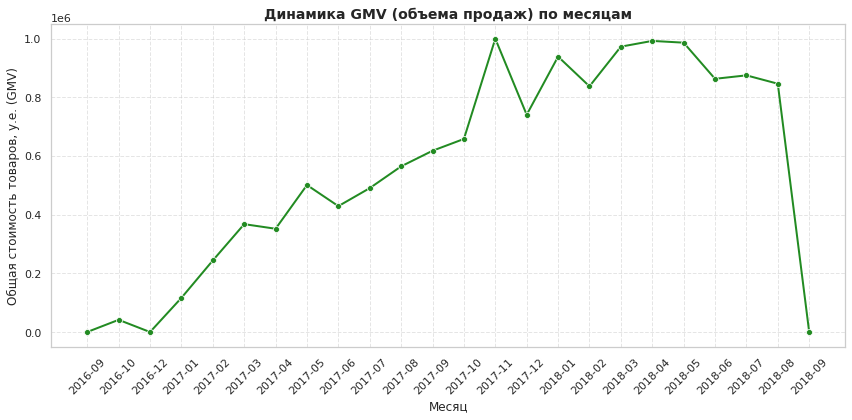

In [84]:
gmv_monthly['month_str'] = gmv_monthly['month'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=gmv_monthly, 
    x='month_str', 
    y='gmv', 
    marker='o', 
    color='forestgreen', 
    linewidth=2
)
plt.title('Динамика GMV (объема продаж) по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Общая стоимость товаров, у.е. (GMV)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [80]:
###Вторая метрика.Объем ценной аудитории: MAU (Monthly Active Customers) — количество уникальных пользователей, которые совершили хотя бы одну успешную покупку в календарный месяц.

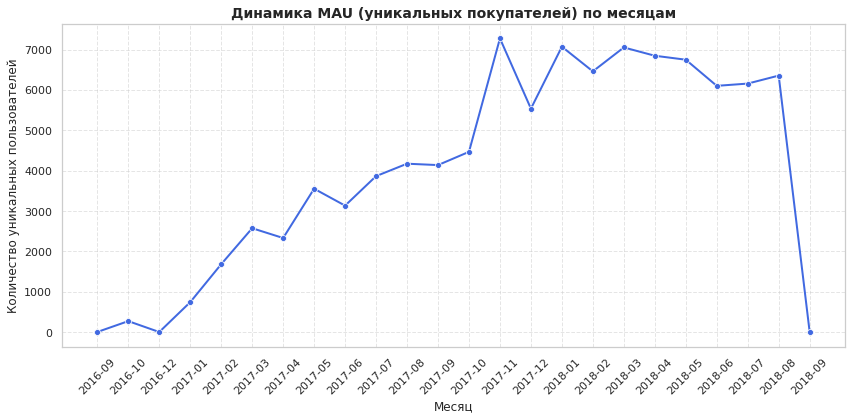

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

mau_monthly['month_str'] = mau_monthly['month'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=mau_monthly, 
    x='month_str', 
    y='mau', 
    marker='o', 
    color='royalblue', 
    linewidth=2
)
plt.title('Динамика MAU (уникальных покупателей) по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [81]:
###Третья метрика.Заинтересованность новых клиентов: Конверсия в первую покупку (CR в покупку) или доля активировавшихся пользователей. На имеющихся данных (так как у нас нет логов посещения сайта) мы рассчитать её не можем, но ее описание таково: отношение числа покупателей к числу уникальных посетителей лендинга.

In [82]:
###Четвертая метрика.Вовлеченность в продолжение использования: Доля повторных покупателей (Repeat Buyer Rate) за месяц. Она показывает, какой процент клиентов от общего числа активных покупателей за месяц делает две и более покупки.

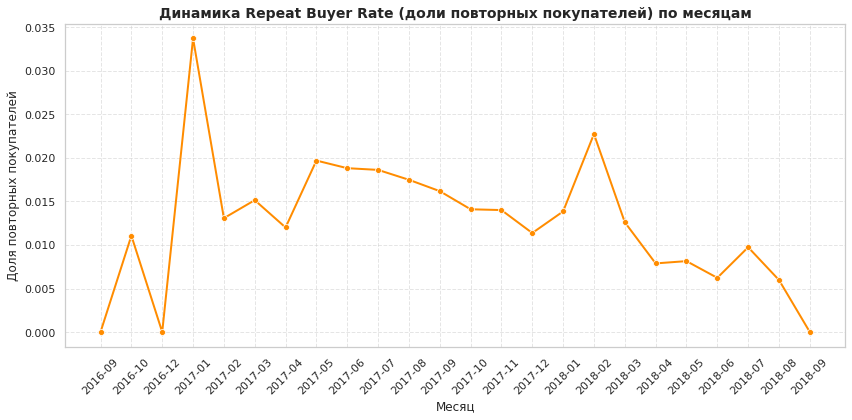

In [86]:
repeat_rate_monthly['month_str'] = repeat_rate_monthly['month'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=repeat_rate_monthly, 
    x='month_str', 
    y='repeat_rate', 
    marker='o', 
    color='darkorange', 
    linewidth=2
)
plt.title('Динамика Repeat Buyer Rate (доли повторных покупателей) по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Доля повторных покупателей', fontsize=12) 
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [83]:
###Пятая метрика.Денежное выражение вовлеченности: ARPPU (Average Revenue Per Paying User) — сколько в среднем приносит один платящий пользователь за месяц.

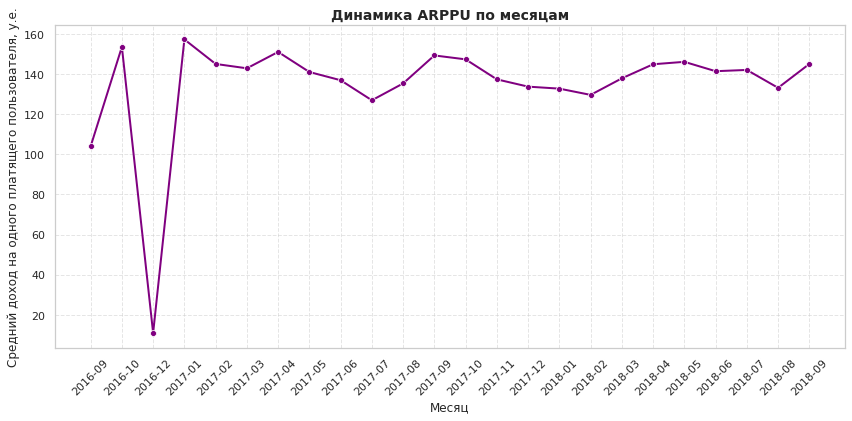

In [88]:
arppu_monthly['month_str'] = arppu_monthly['month'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=arppu_monthly, 
    x='month_str', 
    y='arppu', 
    marker='o', 
    color='purple', 
    linewidth=2
)
plt.title('Динамика ARPPU по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Средний доход на одного платящего пользователя, у.е.', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [89]:
##Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

In [95]:
full_data = user_orders.merge(items, on='order_id', how='inner')

In [98]:
full_data['order_purchase_timestamp'] = pd.to_datetime(full_data['order_purchase_timestamp'])

In [99]:
june_sales = full_data[full_data['order_purchase_timestamp'].dt.to_period('M') == '2017-06']

In [100]:
canceled_count = june_sales[june_sales['order_status'] == 'canceled'].shape[0]

In [101]:
june_sales['order_status'].value_counts()

delivered     3489
shipped         51
processing      18
invoiced        13
canceled        12
Name: order_status, dtype: int64

In [102]:
canceled_statuses = ['canceled', 'unavailable']

In [103]:
june_cancellations = june_sales[june_sales['order_status'].isin(canceled_statuses)]

canceled_count = len(june_cancellations)
print(f"Количество отмененных заказов: {canceled_count}")

Количество отмененных заказов: 12


In [104]:
###Impact по первой гипотезе равен 1.

In [107]:
june_sales = june_sales.copy()

In [108]:
june_sales['order_delivered_customer_date'] = pd.to_datetime(june_sales['order_delivered_customer_date'])
june_sales['order_estimated_delivery_date'] = pd.to_datetime(june_sales['order_estimated_delivery_date'])

In [109]:
delayed_orders = june_sales[june_sales['order_delivered_customer_date'] > june_sales['order_estimated_delivery_date']]

In [110]:
delayed_customers_count = delayed_orders['customer_unique_id'].nunique()
print(f"Количество уникальных клиентов с задержкой доставки: {delayed_customers_count}")

Количество уникальных клиентов с задержкой доставки: 121


In [114]:
order_increase = delayed_customers_count * retention_rate
print(f"Прирост заказов за счет сокращения времени отгрузки: {order_increase:.4f}")

Прирост заказов за счет сокращения времени отгрузки: 0.6125


In [115]:
###Impact по второй гипотезе тоже равен 1.

In [116]:
total_june_customers = june_sales['customer_unique_id'].nunique()
print(f"Всего уникальных клиентов в июне: {total_june_customers}")

Всего уникальных клиентов в июне: 3154


In [117]:
total_june_customers = 3154
retention_rate = 0.0051

In [119]:
customers_no_repeat = total_june_customers * (1 - retention_rate)
order_increase_h3 = customers_no_repeat * retention_rate

print(f"Прирост заказов за счет нового способа оплаты: {order_increase_h3:.4f}")

Прирост заказов за счет нового способа оплаты: 16.0034


In [120]:
###Impact по третьей гипотезе тоже равен 1.

In [122]:
###Выводы: Гипотеза 1 (исправление багов оплаты/отмены):48; Гипотеза 2 (сокращение времени отгрузки):40; Гипотеза 3 (новый способ оплаты):45.
### Выбираем 1 гипотезу.

In [123]:
##Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

In [127]:
###Целевая метрика - Доля успешно доставленных заказов (Delivery Rate) напрямую отражает качество работы всей цепочки маркетплейса — от оплаты до логистики. Если мы исправим баги процессинга, то заказы перестанут отменяться на ранних этапах и будут успешно доходить до клиентов.

In [124]:
total_orders = orders['order_id'].nunique()

In [125]:
delivered_orders = orders[orders['order_status'] == 'delivered']['order_id'].nunique()

In [126]:
delivery_rate = delivered_orders / total_orders

print(f"Общее количество заказов: {total_orders}")
print(f"Количество доставленных заказов: {delivered_orders}")
print(f"Доля успешно доставленных заказов: {delivery_rate:.4f} (или {delivery_rate * 100:.2f}%)")

Общее количество заказов: 99441
Количество доставленных заказов: 96478
Доля успешно доставленных заказов: 0.9702 (или 97.02%)


In [129]:
###Прокси-метрика -  Доля заказов, успешно перешедших в статус approved или processing. Подтверждение оплаты и переход заказа в обработку происходят почти сразу после его создания. Нам не придется ждать несколько недель, пока логистическая служба доставит заказ (как в случае с целевой метрикой), чтобы увидеть первые результаты. Во-вторых, эта метрика находится максимально близко к месту изменения — нашей платежной системе.

In [130]:
approved_orders = orders['order_approved_at'].notna().sum()

In [131]:
approval_rate = approved_orders / total_orders

print(f"Количество заказов с подтвержденной оплатой: {approved_orders}")
print(f"Базовый Approval Rate: {approval_rate:.4f} (или {approval_rate * 100:.2f}%)")

Количество заказов с подтвержденной оплатой: 99281
Базовый Approval Rate: 0.9984 (или 99.84%)


In [132]:
###Барьерная метрика - Среднее время доставки (Delivery Time). Если мы починим баг оплаты, поток заказов вырастет. Но готова ли к этому логистическая служба? Если склад и курьеры не справятся с нагрузкой, время доставки увеличится, и клиенты останутся недовольны. Барьерная метрика «Среднее время доставки» защитит нас от этой проблемы.

In [134]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

In [135]:
delivered_only = orders[orders['order_status'] == 'delivered'].copy()
delivered_only['delivery_time_days'] = (delivered_only['order_delivered_customer_date'] - delivered_only['order_purchase_timestamp']).dt.days

In [136]:
mean_delivery = delivered_only['delivery_time_days'].mean()
median_delivery = delivered_only['delivery_time_days'].median()

print(f"Среднее время доставки: {mean_delivery:.1f} дней")
print(f"Медианное время доставки: {median_delivery:.1f} дней")

Среднее время доставки: 12.1 дней
Медианное время доставки: 10.0 дней
